In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.feature as cfeature
from typing import Dict, List, Tuple
import matplotlib.gridspec as gridspec
from netCDF4 import Dataset
from cartopy import crs as ccrs
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

C:\Users\x12la\AppData\Local\Temp\ipykernel_9680\3830669717.py:2: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


<h1> Import data

In [2]:
# Get lat/lon from LADCO grid and find corners of domain
# this is to be used for map extents
grid='C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc'
# Silly note- DO2 file uses capital LAT LON and d03 uses lowercase 
cmaq_lon,cmaq_lat=np.array(Dataset(grid)['lon']),np.array(Dataset(grid)['lat'])
llat,ulat,llon,ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()
print(llat,ulat,llon,ulon)

#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

# # Load in NHGIS of the 2019-2023 ACS
demo_data = pd.read_csv('../demographic/nhgis0011_ds267_20235_tract.csv')

census_tracts = gpd.read_file('../demographic/cmap_census_tracts2018.shp')
census_tracts = census_tracts.to_crs('EPSG:4326')

40.210953 44.045914 -90.07886 -84.51282


In [21]:
def calc_tract_area_km2(gdf):
    if "tract_area_km2" not in gdf.columns:
        gdf_area = gdf.to_crs("EPSG:5070")
        gdf["tract_area_km2"] = gdf_area.geometry.area / 1e6
    return gdf


def calc_nox_tract_emissions(gdf):
    if "NOX_tons_peryr" in gdf.columns and "NOX_tons_km2_peryr" in gdf.columns:
        return gdf

    for col in ["NO", "NO2"]:
        if col not in gdf.columns:
            raise KeyError(f"Missing '{col}' to derive NOX emissions.")

    calc_tract_area_km2(gdf)

    nox_g_per_s = (
        gdf["NO"] * 30.0061 +
        gdf["NO2"] * 46.005
    )

    gdf["NOX_tons_peryr"] = nox_g_per_s * 3600.0 * 8760.0 / 1e6
    gdf["NOX_tons_km2_peryr"] = gdf["NOX_tons_peryr"] / gdf["tract_area_km2"]

    return gdf


def calc_pm25_tract_emissions(gdf, species=None):
    if "PM25_tons_peryr" in gdf.columns and "PM25_tons_km2_peryr" in gdf.columns:
        return gdf

    if species is None:
        species = [
            "PEC", "POC", "PNCOM", "PSO4", "PNO3", "PFE", "PAL", "PSI",
            "PTI", "PCA", "PMG", "PK", "PMN", "PNA", "PCL", "PMOTHR"
        ]

    missing = [s for s in species if s not in gdf.columns]
    if missing:
        raise KeyError(f"Missing PM2.5 species columns: {missing}")

    calc_tract_area_km2(gdf)

    pm25_g_per_s = gdf[species].sum(axis=1)

    gdf["PM25_tons_peryr"] = pm25_g_per_s * 3600.0 * 8760.0 / 1e6
    gdf["PM25_tons_km2_peryr"] = gdf["PM25_tons_peryr"] / gdf["tract_area_km2"]

    return gdf

In [6]:
# #BASELINE 
gas_base    = gpd.read_file('emis_mole_onroad_gas_2023_average_baseline_censustracts.shp').to_crs('EPSG:4326')
diesel_base = gpd.read_file('emis_mole_onroad_diesel_2023_average_baseline_censustracts.shp').to_crs('EPSG:4326')

# # HDVSpatial
gas_HDVSpatial = gpd.read_file('emis_mole_onroad_gas_2023_average_HDVSpatial_censustracts.shp').to_crs('EPSG:4326')
diesel_HDVSpatial = gpd.read_file('emis_mole_onroad_diesel_2023_average_HPVSpatial_censustracts.shp').to_crs('EPSG:4326')

# LOCUS Idling 
gas_LOCUSIdling    = gpd.read_file('emis_mole_onroad_gas_2023_LOCUSIdling_annualavg_censustracts.shp').to_crs('EPSG:4326')
diesel_LOCUSIdling = gpd.read_file('emis_mole_onroad_diesel_2023_LOCUSIdling_annualavg_censustracts.shp').to_crs('EPSG:4326')

#  LOCUS Idling + HDVSpatial 
gas_LOCUSIdlingHDVSpatial    = gpd.read_file('emis_mole_onroad_gas_2023_LOCUSIdlingHDVSpatial_annualavg_censustracts.shp').to_crs('EPSG:4326')
diesel_LOCUSIdlingHDVSpatial = gpd.read_file('emis_mole_onroad_diesel_2023_LOCUSIdlingHDVSpatial_annualavg_censustracts.shp').to_crs('EPSG:4326')

# Renewal
gas_Renewal    = gpd.read_file('emis_mole_onroad_gas_2023_Renewal_annualavg_censustracts.shp')
gas_Renewal    = gas_Renewal.to_crs('EPSG:4326')
diesel_Renewal = gpd.read_file('emis_mole_onroad_diesel_2023_Renewal_annualavg_censustracts.shp')
diesel_Renewal = diesel_Renewal.to_crs('EPSG:4326')

Zero legacy 
gas_ZeroPre2010s    = gpd.read_file('emis_mole_onroad_gas_2023_ZeroPre2010s_annualavg_censustracts.shp')
gas_ZeroPre2010s   = gas_ZeroPre2010s.to_crs('EPSG:4326')
diesel_ZeroPre2010s = gpd.read_file('emis_mole_onroad_diesel_2023_ZeroPre2010s_annualavg_censustracts.shp')
diesel_ZeroPre2010s = diesel_ZeroPre2010s.to_crs('EPSG:4326')

In [7]:
EXCLUDE_COLS = ['geometry', 'lat', 'lon', 'lat_m', 'lon_m']

def make_onroad_total(gas_df, diesel_df):
    common_cols = [c for c in gas_df.columns if c in diesel_df.columns]

    cols_to_sum = [
        c for c in common_cols
        if c not in EXCLUDE_COLS
        and np.issubdtype(gas_df[c].dtype, np.number)
    ]

    total_df = gas_df.copy()
    total_df[cols_to_sum] = (
        gas_df[cols_to_sum].fillna(0).to_numpy()
        + diesel_df[cols_to_sum].fillna(0).to_numpy()
    )

    return total_df, cols_to_sum


# BASELINE
onroad_total_base, cols_to_sum_base = make_onroad_total(
    gas_base, diesel_base
)

# HDVSpatial
onroad_total_HDVSpatial, cols_to_sum_HDVSpatial = make_onroad_total(
    gas_HDVSpatial, diesel_HDVSpatial
)

# LOCUS Idling
onroad_total_LOCUSIdling, cols_to_sum_LOCUSIdling = make_onroad_total(
    gas_LOCUSIdling, diesel_LOCUSIdling
)

# LOCUS Idling + HDVSpatial
onroad_total_LOCUSIdlingHDVSpatial, cols_to_sum_LOCUSIdlingHDVSpatial = make_onroad_total(
    gas_LOCUSIdlingHDVSpatial, diesel_LOCUSIdlingHDVSpatial
)

# Renewal
onroad_total_Renewal, cols_to_sum_Renewal = make_onroad_total(
    gas_Renewal, diesel_Renewal
)

# Zero legacy / ZeroPre2010s
onroad_total_ZeroPre2010s, cols_to_sum_ZeroPre2010s = make_onroad_total(
    gas_ZeroPre2010s, diesel_ZeroPre2010s
)


# ======================================================
# sanity checks :')
# ======================================================
print("Baseline totals shape:", onroad_total_base.shape)
print("HDVSpatial totals shape:", onroad_total_HDVSpatial.shape)
print("LOCUSIdling totals shape:", onroad_total_LOCUSIdling.shape)
print("LOCUSIdlingHDVSpatial totals shape:", onroad_total_LOCUSIdlingHDVSpatial.shape)
print("Renewal totals shape:", onroad_total_Renewal.shape)
print("ZeroPre2010s totals shape:", onroad_total_ZeroPre2010s.shape)

Baseline totals shape: (4393, 65)
HDVSpatial totals shape: (4393, 65)
LOCUSIdling totals shape: (4393, 65)
LOCUSIdlingHDVSpatial totals shape: (4393, 65)
Renewal totals shape: (4393, 65)
ZeroPre2010s totals shape: (4393, 65)


In [8]:
demo_joined = census_tracts.merge(demo_data, on='GISJOIN')

cmap_tracts = gpd.clip(census_tracts, cmap_cty)
cmap_demo = gpd.clip(demo_joined, cmap_cty)

domain_tracts = gpd.clip(census_tracts, onroad_total_base)
domain_demo = gpd.clip(demo_joined, onroad_total_base)

onroad_total_base_cmap = gpd.clip(onroad_total_base, cmap_cty)
onroad_total_LOCUSIdling_cmap = gpd.clip(onroad_total_LOCUSIdling, cmap_cty)
onroad_total_HDVSpatial_cmap = gpd.clip(onroad_total_HDVSpatial, cmap_cty)
onroad_total_LOCUSIdlingHDVSpatial_cmap = gpd.clip(onroad_total_LOCUSIdlingHDVSpatial, cmap_cty)
onroad_total_Renewal_cmap = gpd.clip(onroad_total_Renewal, cmap_cty)
onroad_total_ZeroPre2010s_cmap = gpd.clip(onroad_total_ZeroPre2010s, cmap_cty)

In [23]:
base_nox_cmap = onroad_total_base_cmap.copy()
s1_nox_cmap   = onroad_total_LOCUSIdling_cmap.copy()
s2_nox_cmap   = onroad_total_HDVSpatial_cmap.copy()
s3_nox_cmap   = onroad_total_LOCUSIdlingHDVSpatial_cmap.copy()
renewal_nox_cmap = onroad_total_Renewal_cmap.copy()
zero_nox_cmap    = onroad_total_ZeroPre2010s_cmap.copy()


# PM2.5 scenario dataframes
base_pm_cmap = onroad_total_base_cmap.copy()
s1_pm_cmap   = onroad_total_LOCUSIdling_cmap.copy()
s2_pm_cmap   = onroad_total_HDVSpatial_cmap.copy()
s3_pm_cmap   = onroad_total_LOCUSIdlingHDVSpatial_cmap.copy()
renewal_pm_cmap = onroad_total_Renewal_cmap.copy()
zero_pm_cmap    = onroad_total_ZeroPre2010s_cmap.copy()

In [24]:
for gdf in [
    base_nox_cmap, s1_nox_cmap, s2_nox_cmap, s3_nox_cmap, renewal_nox_cmap, zero_nox_cmap,
    base_pm_cmap, s1_pm_cmap, s2_pm_cmap, s3_pm_cmap, renewal_pm_cmap, zero_pm_cmap
]:
    calc_nox_peryear(gdf)
    calc_pm25_peryear(gdf)

for gdf in [
    base_nox_cmap, s1_nox_cmap, s2_nox_cmap, s3_nox_cmap, renewal_nox_cmap, zero_nox_cmap,
    base_pm_cmap, s1_pm_cmap, s2_pm_cmap, s3_pm_cmap, renewal_pm_cmap, zero_pm_cmap
]:
    gdf.rename(columns={
        "NOX_peryear": "NOX_peryr",
        "PM25_peryear": "PM25_peryr"
    }, inplace=True)

In [25]:
base_nox_cmap["diff_s1_nox"] = s1_nox_cmap["NOX_peryr"] - base_nox_cmap["NOX_peryr"]
base_nox_cmap["diff_s2_nox"] = s2_nox_cmap["NOX_peryr"] - base_nox_cmap["NOX_peryr"]
base_nox_cmap["diff_s3_nox"] = s3_nox_cmap["NOX_peryr"] - base_nox_cmap["NOX_peryr"]
base_nox_cmap["diff_renewal_nox"] = renewal_nox_cmap["NOX_peryr"] - base_nox_cmap["NOX_peryr"]
base_nox_cmap["diff_zero_nox"] = zero_nox_cmap["NOX_peryr"] - base_nox_cmap["NOX_peryr"]

base_pm_cmap["diff_s1_pm25"] = s1_pm_cmap["PM25_peryr"] - base_pm_cmap["PM25_peryr"]
base_pm_cmap["diff_s2_pm25"] = s2_pm_cmap["PM25_peryr"] - base_pm_cmap["PM25_peryr"]
base_pm_cmap["diff_s3_pm25"] = s3_pm_cmap["PM25_peryr"] - base_pm_cmap["PM25_peryr"]
base_pm_cmap["diff_renewal_pm25"] = renewal_pm_cmap["PM25_peryr"] - base_pm_cmap["PM25_peryr"]
base_pm_cmap["diff_zero_pm25"] = zero_pm_cmap["PM25_peryr"] - base_pm_cmap["PM25_peryr"]

# Differences from LOCUSIdlingHDVSpatial scenario
base_nox_cmap["diff_renewal_from_s3_nox"] = renewal_nox_cmap["NOX_peryr"] - s3_nox_cmap["NOX_peryr"]
base_nox_cmap["diff_zero_from_s3_nox"] = zero_nox_cmap["NOX_peryr"] - s3_nox_cmap["NOX_peryr"]

base_pm_cmap["diff_renewal_from_s3_pm25"] = renewal_pm_cmap["PM25_peryr"] - s3_pm_cmap["PM25_peryr"]
base_pm_cmap["diff_zero_from_s3_pm25"] = zero_pm_cmap["PM25_peryr"] - s3_pm_cmap["PM25_peryr"]

In [26]:
# Extent for plots 
minx, miny, maxx, maxy = cmap_cty.total_bounds
extent_xy = (minx, maxx, miny, maxy)

In [27]:
# helper func for plots
def annotate_max(ax, gdf, col, fmt="{:.2f}", color="black"):
    vals = gdf[col].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vmax = float(np.max(vals)) if vals.size else np.nan

    ax.text(
        0.02, 0.02,
        f"Max: {fmt.format(vmax)}",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=10,
        color=color,
        bbox=dict(facecolor="white", alpha=0.70, boxstyle="round,pad=0.25", linewidth=0)
    )

<h1> Visualize data 

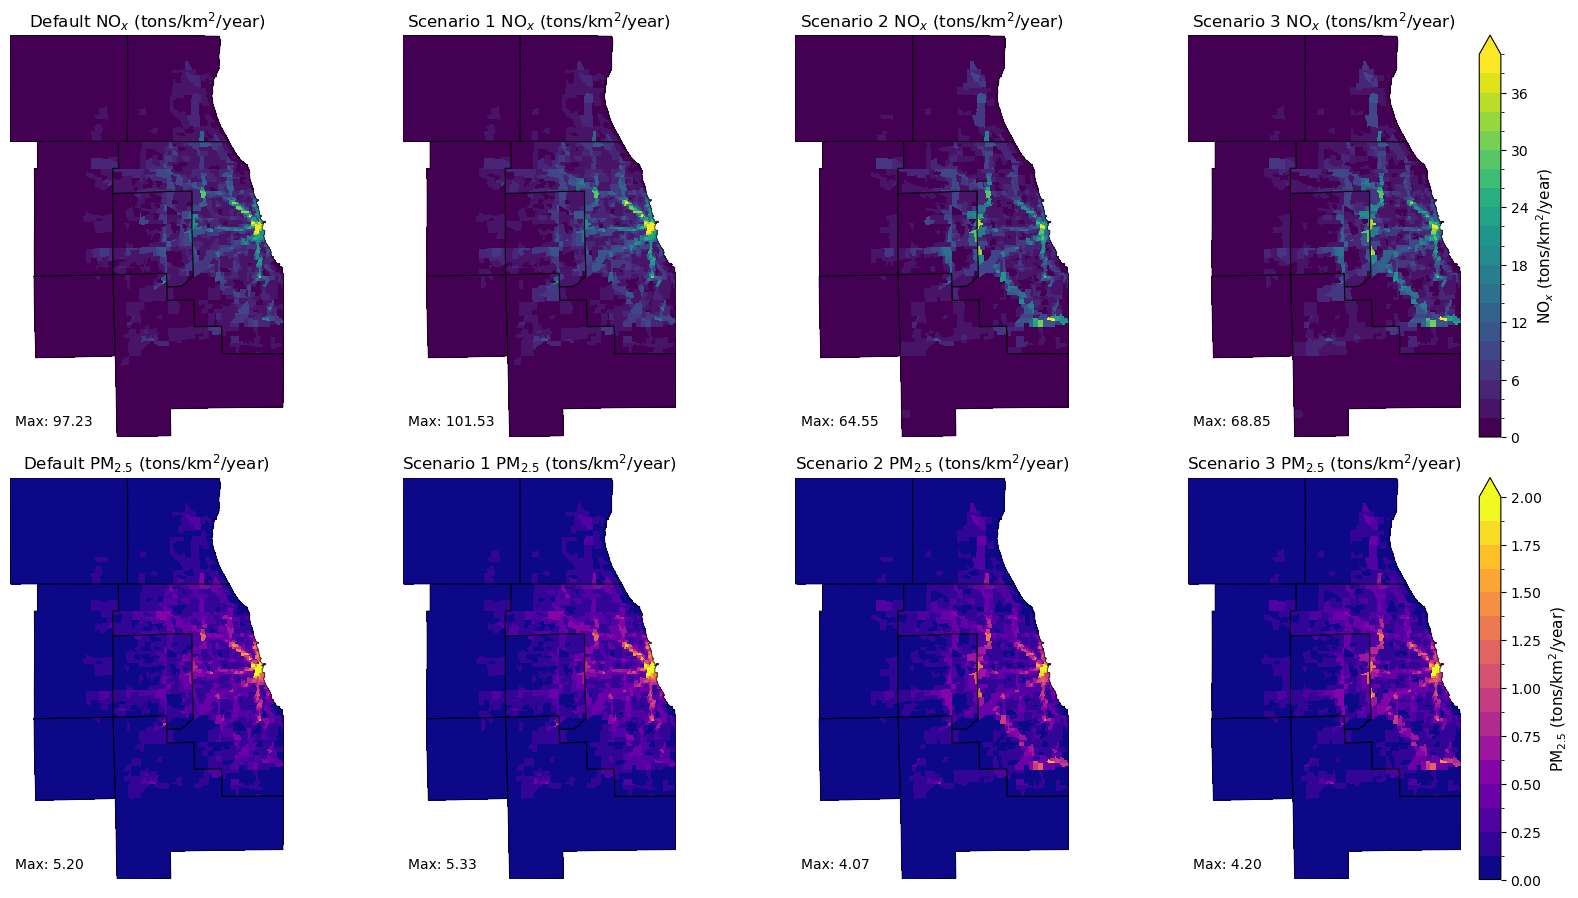

In [28]:
# set up fig
NOX_N_BINS = 20
NOX_VMIN   = 0.0
NOX_VMAX   = 40.0

PM25_N_BINS = 16
PM25_VMIN   = 0.0
PM25_VMAX   = 2.0

viridis_disc_nox = ListedColormap(plt.cm.viridis(np.linspace(0, 1, NOX_N_BINS)))
bounds_base_nox  = np.linspace(NOX_VMIN, NOX_VMAX, NOX_N_BINS + 1)
norm_base_nox    = BoundaryNorm(bounds_base_nox, viridis_disc_nox.N)

viridis_disc_pm  = ListedColormap(plt.cm.plasma(np.linspace(0, 1, PM25_N_BINS)))
bounds_base_pm   = np.linspace(PM25_VMIN, PM25_VMAX, PM25_N_BINS + 1)
norm_base_pm     = BoundaryNorm(bounds_base_pm, viridis_disc_pm.N)

fig, axs = plt.subplots(
    nrows=2, ncols=4, figsize=(18, 9),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axs = axs.ravel()

# NOx absolute panels ---
nox_panels = [
    ("Default NO$_x$ (tons/km$^2$/year)", base_nox_cmap, "NOX_peryr"),
    ("Scenario 1 NO$_x$ (tons/km$^2$/year)", s1_nox_cmap, "NOX_peryr"),
    ("Scenario 2 NO$_x$ (tons/km$^2$/year)", s2_nox_cmap, "NOX_peryr"),
    ("Scenario 3 NO$_x$ (tons/km$^2$/year)", s3_nox_cmap, "NOX_peryr"),
]
for i, (ttl, gdf, col) in enumerate(nox_panels):
    ax = axs[i]
    gdf.plot(col, ax=ax, cmap=viridis_disc_nox, norm=norm_base_nox,
             edgecolor="none", antialiased=False, vmin=NOX_VMIN, vmax=NOX_VMAX)
    ax.set_title(ttl, fontsize=12)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.6, linewidth=0.8)
    ax.set_axis_off()
    annotate_max(ax, gdf, col, fmt="{:.2f}", color="black")

# PM2.5 
pm_panels = [
    ("Default PM$_{2.5}$ (tons/km$^2$/year)", base_pm_cmap, "PM25_peryr"),
    ("Scenario 1 PM$_{2.5}$ (tons/km$^2$/year)", s1_pm_cmap, "PM25_peryr"),
    ("Scenario 2 PM$_{2.5}$ (tons/km$^2$/year)", s2_pm_cmap, "PM25_peryr"),
    ("Scenario 3 PM$_{2.5}$ (tons/km$^2$/year)", s3_pm_cmap, "PM25_peryr"),
]
for j, (ttl, gdf, col) in enumerate(pm_panels):
    ax = axs[4 + j]
    gdf.plot(col, ax=ax, cmap=viridis_disc_pm, norm=norm_base_pm,
             edgecolor="none", antialiased=False, vmin=PM25_VMIN, vmax=PM25_VMAX)
    ax.set_title(ttl, fontsize=12)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.6, linewidth=0.8)
    ax.set_axis_off()
    annotate_max(ax, gdf, col, fmt="{:.2f}", color="black")

plt.tight_layout(rect=[0.00, 0.00, 0.93, 1.00])  # reserve right margin for colorbars

# -----------------------
# Colorbar hell
# -----------------------
top_row_axes = [axs[0], axs[1], axs[2], axs[3]]
bot_row_axes = [axs[4], axs[5], axs[6], axs[7]]

top_pos = [a.get_position() for a in top_row_axes]
bot_pos = [a.get_position() for a in bot_row_axes]

# Row vertical extents
top_y0 = min(p.y0 for p in top_pos); top_y1 = max(p.y1 for p in top_pos)
bot_y0 = min(p.y0 for p in bot_pos); bot_y1 = max(p.y1 for p in bot_pos)

# Put cbar just to the right of the last column -harder than it sounds
right_edge = max(p.x1 for p in top_pos + bot_pos)
pad = 0.01
cbar_w = 0.012

cax_nox = fig.add_axes([right_edge + pad, top_y0, cbar_w, (top_y1 - top_y0)])
cax_pm  = fig.add_axes([right_edge + pad, bot_y0, cbar_w, (bot_y1 - bot_y0)])

cbar1 = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_base_nox, cmap=viridis_disc_nox),
    cax=cax_nox, extend="max"
)
cbar1.set_label("NO$_x$ (tons/km$^2$/year)", fontsize=11)

cbar2 = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_base_pm, cmap=viridis_disc_pm),
    cax=cax_pm, extend="max"
)
cbar2.set_label("PM$_{2.5}$ (tons/km$^2$/year)", fontsize=11)

plt.show()

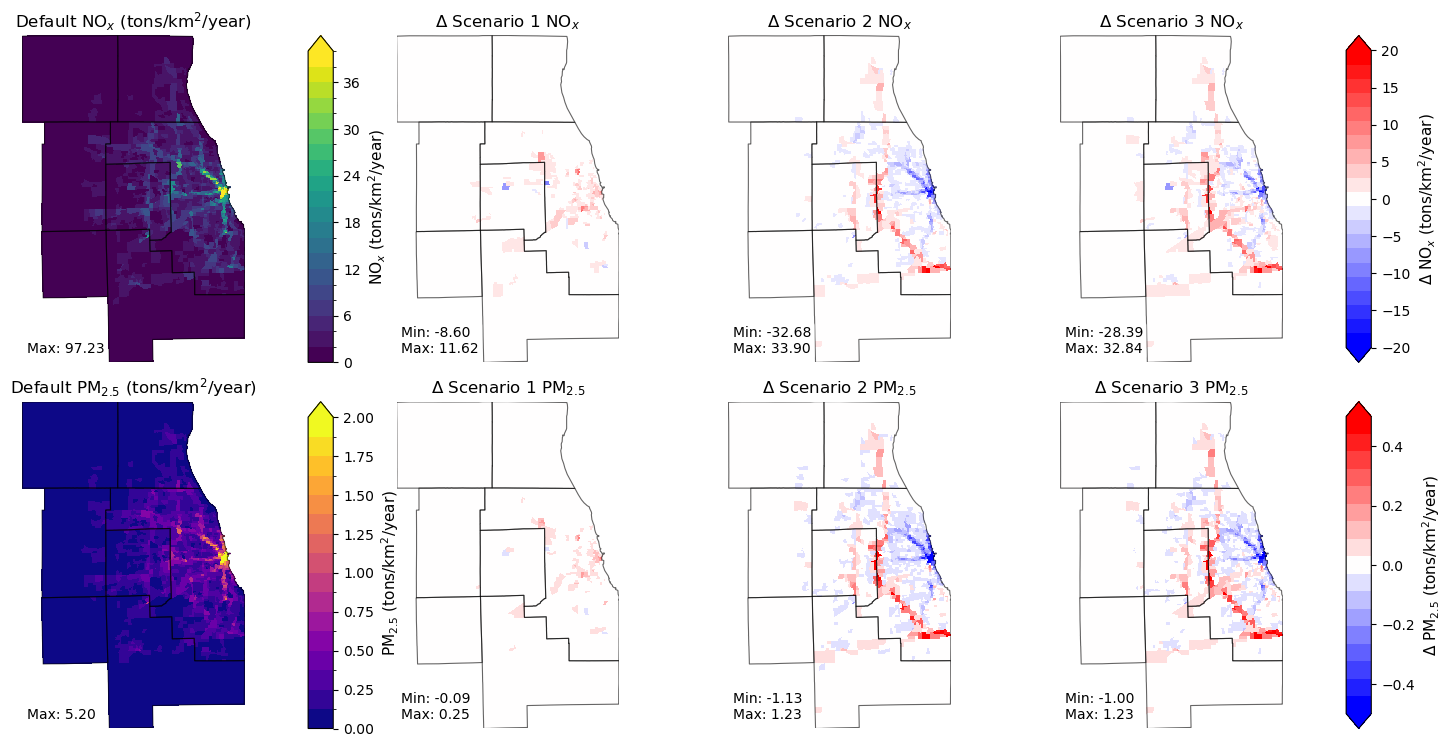

In [29]:
def annotate_max(ax, gdf, col, fmt="{:.2f}", color="black"):
    vals = gdf[col].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(
        0.02, 0.02, f"Max: {fmt.format(vmax)}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=10, color=color,
        bbox=dict(facecolor="white", alpha=0.70, boxstyle="round,pad=0.25", linewidth=0)
    )

def annotate_minmax(ax, gdf, col, fmt="{:.2f}", color="black"):
    vals = gdf[col].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vmin = float(np.min(vals)) if vals.size else np.nan
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(
        0.02, 0.02, f"Min: {fmt.format(vmin)}\nMax: {fmt.format(vmax)}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=10, color=color,
        bbox=dict(facecolor="white", alpha=0.70, boxstyle="round,pad=0.25", linewidth=0)
    )

# -----------------------------
# diff settings 
# -----------------------------
NOX_DIFF_MIN = -20.0
NOX_DIFF_MAX =  20.0
PM25_DIFF_MIN = -0.5
PM25_DIFF_MAX =  0.5

N_DIFF_NOX = NOX_N_BINS if (NOX_N_BINS % 2 == 1) else (NOX_N_BINS + 1)
bwr_disc_nox = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_NOX)))
norm_diff_nox = TwoSlopeNorm(vmin=NOX_DIFF_MIN, vcenter=0.0, vmax=NOX_DIFF_MAX)

N_DIFF_PM = PM25_N_BINS if (PM25_N_BINS % 2 == 1) else (PM25_N_BINS + 1)
bwr_disc_pm = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_PM)))
norm_diff_pm = TwoSlopeNorm(vmin=PM25_DIFF_MIN, vcenter=0.0, vmax=PM25_DIFF_MAX)

nox_panels = [
    ("Default NO$_x$ (tons/km$^2$/year)",                base_nox_cmap, "NOX_peryr",  viridis_disc_nox, norm_base_nox, NOX_VMIN,     NOX_VMAX,     "max"),
    ("Δ Scenario 1 NO$_x$", base_nox_cmap, "diff_s1_nox",  bwr_disc_nox,     norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX, "minmax"),
    ("Δ Scenario 2 NO$_x$", base_nox_cmap, "diff_s2_nox",  bwr_disc_nox,     norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX, "minmax"),
    ("Δ Scenario 3 NO$_x$", base_nox_cmap, "diff_s3_nox",  bwr_disc_nox,     norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX, "minmax"),
]

pm_panels = [
    ("Default PM$_{2.5}$ (tons/km$^2$/year)",                base_pm_cmap, "PM25_peryr",   viridis_disc_pm, norm_base_pm, PM25_VMIN,     PM25_VMAX,     "max"),
    ("Δ Scenario 1 PM$_{2.5}$", base_pm_cmap, "diff_s1_pm25",   bwr_disc_pm,     norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX, "minmax"),
    ("Δ Scenario 2 PM$_{2.5}$", base_pm_cmap, "diff_s2_pm25",   bwr_disc_pm,     norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX, "minmax"),
    ("Δ Scenario 3 PM$_{2.5}$", base_pm_cmap, "diff_s3_pm25",   bwr_disc_pm,     norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX, "minmax"),
]

fig = plt.figure(figsize=(18, 9))
gs = gridspec.GridSpec(
    nrows=2, ncols=6, figure=fig,
    width_ratios=[1.00, 0.08, 1.00, 1.00, 1.00, 0.08],
    wspace=0.08, hspace=0.12
)

# map axes
ax_nox = [fig.add_subplot(gs[0, c], projection=ccrs.PlateCarree()) for c in [0, 2, 3, 4]]
ax_pm  = [fig.add_subplot(gs[1, c], projection=ccrs.PlateCarree()) for c in [0, 2, 3, 4]]

# colorbar axes (paired to "column 1" and "diff columns")
cax_abs_nox  = fig.add_subplot(gs[0, 1])  # with map 0
cax_diff_nox = fig.add_subplot(gs[0, 5])  # with maps 1-3 
cax_abs_pm   = fig.add_subplot(gs[1, 1])
cax_diff_pm  = fig.add_subplot(gs[1, 5])

# -----------------------------
# plot NOx row (4 panels)
# -----------------------------
for i, (ttl, gdf, col, cmap_use, norm_use, vmin, vmax, ann) in enumerate(nox_panels):
    ax = ax_nox[i]
    gdf.plot(col, ax=ax, cmap=cmap_use, norm=norm_use,
             edgecolor="none", antialiased=False, vmin=vmin, vmax=vmax)
    ax.set_title(ttl, fontsize=12)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.6, linewidth=0.8)
    ax.set_axis_off()

    if ann == "max":
        annotate_max(ax, gdf, col, fmt="{:.2f}")
    else:
        annotate_minmax(ax, gdf, col, fmt="{:.2f}")

# -----------------------------
# plot PM row (4 panels)
# -----------------------------
for i, (ttl, gdf, col, cmap_use, norm_use, vmin, vmax, ann) in enumerate(pm_panels):
    ax = ax_pm[i]
    gdf.plot(col, ax=ax, cmap=cmap_use, norm=norm_use,
             edgecolor="none", antialiased=False, vmin=vmin, vmax=vmax)
    ax.set_title(ttl, fontsize=12)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.6, linewidth=0.8)
    #ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.6, edgecolor="black", zorder=10)
    ax.set_axis_off()

    if ann == "max":
        annotate_max(ax, gdf, col, fmt="{:.2f}")
    else:
        annotate_minmax(ax, gdf, col, fmt="{:.2f}")

# -----------------------------
# colorbar hell again -> some of this code may not be necessary but it works and im afraid to remove anything to see
#   abs cbar = same scale as col1 (Default)
#   diff cbar = same scale for cols2-4 (Scenario diffs)
# -----------------------------
cb_abs_nox = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_base_nox, cmap=viridis_disc_nox),
    cax=cax_abs_nox, extend="max"
)
cb_abs_nox.set_label("NO$_x$ (tons/km$^2$/year)", fontsize=11)

cb_diff_nox = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_diff_nox, cmap=bwr_disc_nox),
    cax=cax_diff_nox, extend="both"
)
cb_diff_nox.set_label("Δ NO$_x$ (tons/km$^2$/year)", fontsize=11)

cb_abs_pm = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_base_pm, cmap=viridis_disc_pm),
    cax=cax_abs_pm, extend="max"
)
cb_abs_pm.set_label("PM$_{2.5}$ (tons/km$^2$/year)", fontsize=11)

cb_diff_pm = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_diff_pm, cmap=bwr_disc_pm),
    cax=cax_diff_pm, extend="both"
)
cb_diff_pm.set_label("Δ PM$_{2.5}$ (tons/km$^2$/year)", fontsize=11)

plt.show()

<h1> Calc pop-weighted emissions

In [30]:
POP_TOTAL = "ASOAE001"
POP_WHITE = "ASOAE003"
POP_BLACK = "ASOAE004"
POP_ASIAN = "ASOAE006"
POP_HISP  = "ASOAE012"

def wmean(v, w):
    v = np.asarray(v, float)
    w = np.asarray(w, float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if not np.any(m):
        return np.nan
    return float(np.average(v[m], weights=w[m]))

def join_demo(emis_gdf, demo_gdf, value_col):
    emis_sub = emis_gdf[["GISJOIN", value_col, "geometry"]].copy()

    # drop demo geometry to avoid conflicts, then merge
    demo_sub = demo_gdf.drop(columns=["geometry"], errors="ignore").copy()
    joined = demo_sub.merge(emis_sub, on="GISJOIN", how="inner")

    # restore geodataframe
    joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=emis_gdf.crs)

    # compute OTHER_POP
    joined["OTHER_POP"] = joined[POP_TOTAL] - (joined[POP_WHITE] + joined[POP_BLACK] + joined[POP_ASIAN] + joined[POP_HISP])
    joined["OTHER_POP"] = joined["OTHER_POP"].clip(lower=0)

    return joined

In [31]:
# ============================================================
# A) JOIN ALL DATASETS
# ============================================================

base_nox_j = join_demo(base_nox_cmap, cmap_demo, "NOX_peryr")
s1_nox_j = join_demo(s1_nox_cmap, cmap_demo, "NOX_peryr")
s2_nox_j = join_demo(s2_nox_cmap, cmap_demo, "NOX_peryr")
s3_nox_j = join_demo(s3_nox_cmap, cmap_demo, "NOX_peryr")
renewal_nox_j = join_demo(renewal_nox_cmap, cmap_demo, "NOX_peryr")
zero_nox_j = join_demo(zero_nox_cmap, cmap_demo, "NOX_peryr")

base_pm_j = join_demo(base_pm_cmap, cmap_demo, "PM25_peryr")
s1_pm_j = join_demo(s1_pm_cmap, cmap_demo, "PM25_peryr")
s2_pm_j = join_demo(s2_pm_cmap, cmap_demo, "PM25_peryr")
s3_pm_j = join_demo(s3_pm_cmap, cmap_demo, "PM25_peryr")
renewal_pm_j = join_demo(renewal_pm_cmap, cmap_demo, "PM25_peryr")
zero_pm_j = join_demo(zero_pm_cmap, cmap_demo, "PM25_peryr")


# ============================================================
# B) POP-WEIGHTED MEAN FUNCTION BY GROUP
# ============================================================

groups = {
    "Total": POP_TOTAL,
    "White": POP_WHITE,
    "Black": POP_BLACK,
    "Hispanic": POP_HISP,
    "Asian": POP_ASIAN,
    "Other": "OTHER_POP"
}

nox_joined = {
    "Base": base_nox_j,
    "S1": s1_nox_j,
    "S2": s2_nox_j,
    "S3": s3_nox_j,
    "Renewal": renewal_nox_j,
    "Zero": zero_nox_j
}

pm_joined = {
    "Base": base_pm_j,
    "S1": s1_pm_j,
    "S2": s2_pm_j,
    "S3": s3_pm_j,
    "Renewal": renewal_pm_j,
    "Zero": zero_pm_j
}

nox_means = {
    scen: {grp: wmean(gdf["NOX_peryr"], gdf[pop_col]) for grp, pop_col in groups.items()}
    for scen, gdf in nox_joined.items()
}

pm_means = {
    scen: {grp: wmean(gdf["PM25_peryr"], gdf[pop_col]) for grp, pop_col in groups.items()}
    for scen, gdf in pm_joined.items()
}


# ============================================================
# C) TABLES
# ============================================================

nox_tbl = pd.DataFrame(nox_means).loc[["White", "Black", "Hispanic", "Asian", "Other"]]
pm_tbl = pd.DataFrame(pm_means).loc[["White", "Black", "Hispanic", "Asian", "Other"]]

nox_tbl_abs = nox_tbl.copy()
pm_tbl_abs = pm_tbl.copy()

for scen in nox_tbl_abs.columns:
    nox_tbl_abs[scen + "_Absolute"] = nox_tbl_abs[scen] - nox_means[scen]["Total"]
    nox_tbl_abs = nox_tbl_abs.drop(columns=[scen])

for scen in pm_tbl_abs.columns:
    pm_tbl_abs[scen + "_Absolute"] = pm_tbl_abs[scen] - pm_means[scen]["Total"]
    pm_tbl_abs = pm_tbl_abs.drop(columns=[scen])

nox_tbl_rel = nox_tbl.copy()
pm_tbl_rel = pm_tbl.copy()

for scen in nox_tbl_rel.columns:
    nox_tbl_rel[scen + "_Relative"] = nox_tbl_rel[scen] / nox_means[scen]["Total"]
    nox_tbl_rel = nox_tbl_rel.drop(columns=[scen])

for scen in pm_tbl_rel.columns:
    pm_tbl_rel[scen + "_Relative"] = pm_tbl_rel[scen] / pm_means[scen]["Total"]
    pm_tbl_rel = pm_tbl_rel.drop(columns=[scen])

print("\n=== NOX means by group ===")
print(nox_tbl)
print("\n=== NOX absolute disparities group - domain mean ===")
print(nox_tbl_abs)
print("\n=== NOX relative disparities group / domain mean ===")
print(nox_tbl_rel)

print("\n=== PM means by group ===")
print(pm_tbl)
print("\n=== PM absolute disparities group - domain mean ===")
print(pm_tbl_abs)
print("\n=== PM relative disparities group / domain mean ===")
print(pm_tbl_rel)




=== NOX means by group ===
              Base        S1        S2        S3   Renewal      Zero
White     4.799189  5.163381  3.940151  4.304343  3.170174  2.977510
Black     5.637503  6.018633  4.878986  5.260115  3.822544  3.504769
Hispanic  4.707522  5.327313  4.028866  4.648656  3.466686  3.256772
Asian     7.110691  7.651644  5.774319  6.315272  4.598761  4.270366
Other     5.491499  5.905462  4.461460  4.875423  3.583440  3.342865

=== NOX absolute disparities group - domain mean ===
          Base_Absolute  S1_Absolute  S2_Absolute  S3_Absolute  \
White         -0.306628    -0.387646    -0.327340    -0.408357   
Black          0.531686     0.467607     0.611494     0.547415   
Hispanic      -0.398295    -0.223714    -0.238626    -0.064044   
Asian          2.004874     2.100617     1.506828     1.602571   
Other          0.385682     0.354436     0.193969     0.162723   

          Renewal_Absolute  Zero_Absolute  
White            -0.298918      -0.262635  
Black             0

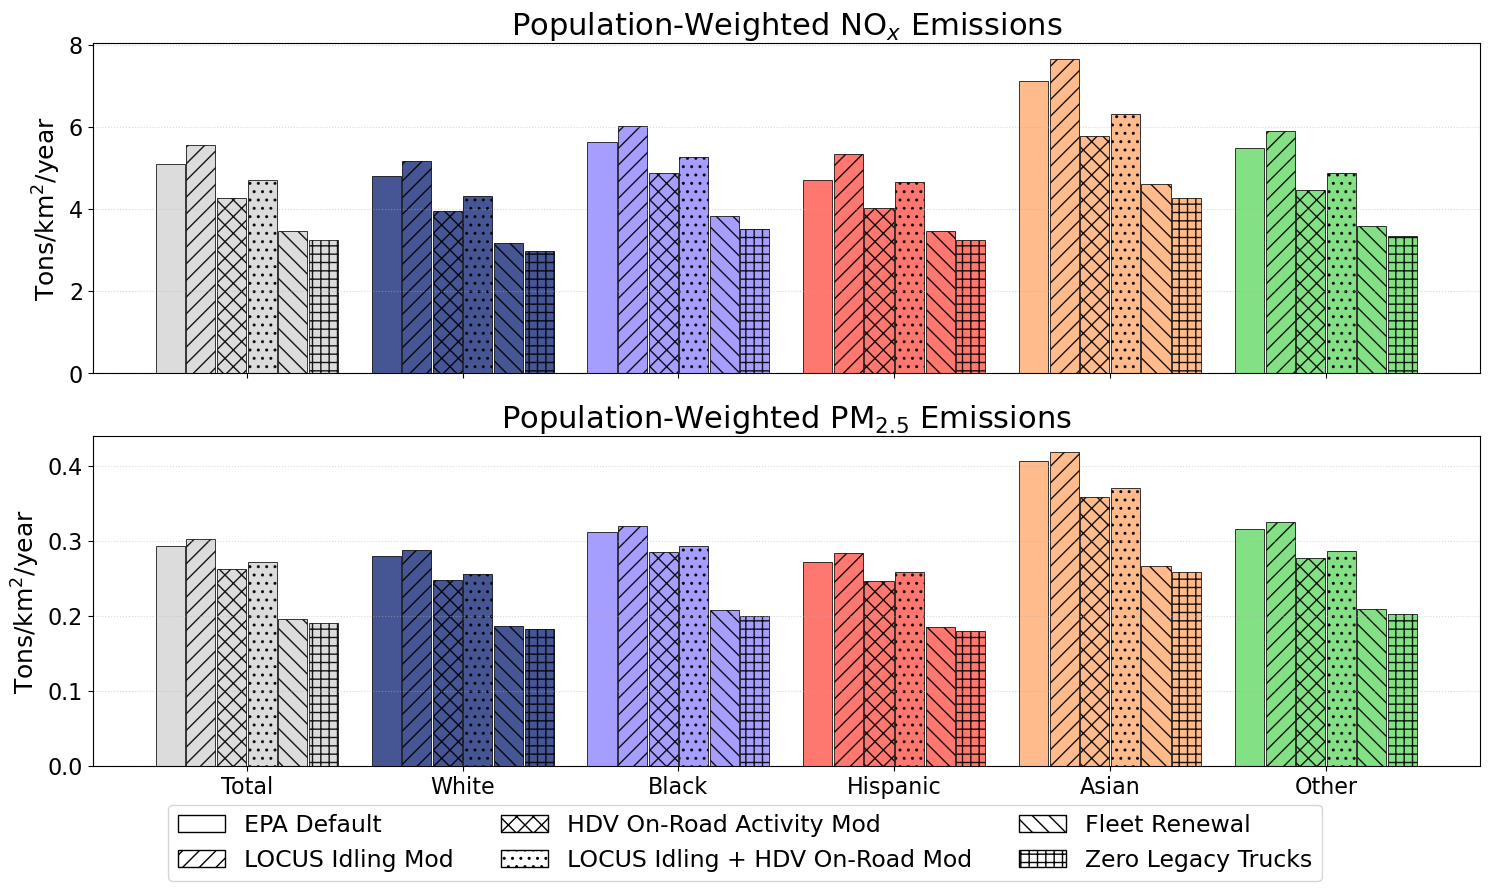

In [49]:
# ============================================================
# D) POPULATION-WEIGHTED BAR CHART
# ============================================================

subgroups_for_plot = ["Total", "White", "Black", "Hispanic", "Asian", "Other"]

colors_for_plot = {
    "Total": "#d9d9d9",
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77"
}

hatches = {
    "Base": "",
    "S1": "//",
    "S2": "xx",
    "S3": "..",
    "Renewal": "\\\\",
    "Zero": "++"
}

scenario_keys = ["Base", "S1", "S2", "S3", "Renewal", "Zero"]
scenario_labels = [
    "EPA Default",
    "LOCUS Idling Mod",
    "HDV On-Road Activity Mod",
    "LOCUS Idling + HDV On-Road Mod",
    "Fleet Renewal",
    "Zero Legacy Trucks"
]

nox_vals = np.array([
    [nox_means[scen][grp] for grp in subgroups_for_plot]
    for scen in scenario_keys
], dtype=float)

pm_vals = np.array([
    [pm_means[scen][grp] for grp in subgroups_for_plot]
    for scen in scenario_keys
], dtype=float)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

x = np.arange(len(subgroups_for_plot))
cluster_w = 0.85
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys) - 1) / 2) * bar_w

ax = axes[0]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(x[i] + offsets[s], nox_vals[s, i], width=bar_w * 0.95, color=colors_for_plot[g], hatch=hatches[key], edgecolor="black", linewidth=0.6, alpha=0.9)
axes[0].set_ylabel("Tons/km$^2$/year", fontsize=18)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
axes[0].tick_params(axis="y", labelsize=16)

ax.set_title("Population-Weighted NO$_x$ Emissions", fontsize=22)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis="y", labelsize=16)

ax = axes[1]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(x[i] + offsets[s], pm_vals[s, i], width=bar_w * 0.95, color=colors_for_plot[g], hatch=hatches[key], edgecolor="black", linewidth=0.6, alpha=0.9)

ax.set_title("Population-Weighted PM$_{2.5}$ Emissions", fontsize=22)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis="y", labelsize=16)

axes[1].set_xticks(x)
axes[1].set_xticklabels(subgroups_for_plot, fontsize=16)

scenario_patches = [
    mpatches.Patch(facecolor="white", edgecolor="black", hatch=hatches[k], label=scenario_labels[i])
    for i, k in enumerate(scenario_keys)
]

axes[1].set_ylabel("Tons/km$^2$/year", fontsize=18)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
axes[1].tick_params(axis="y", labelsize=16)


fig.legend(handles=scenario_patches, fontsize=17, loc="lower center", ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.show()

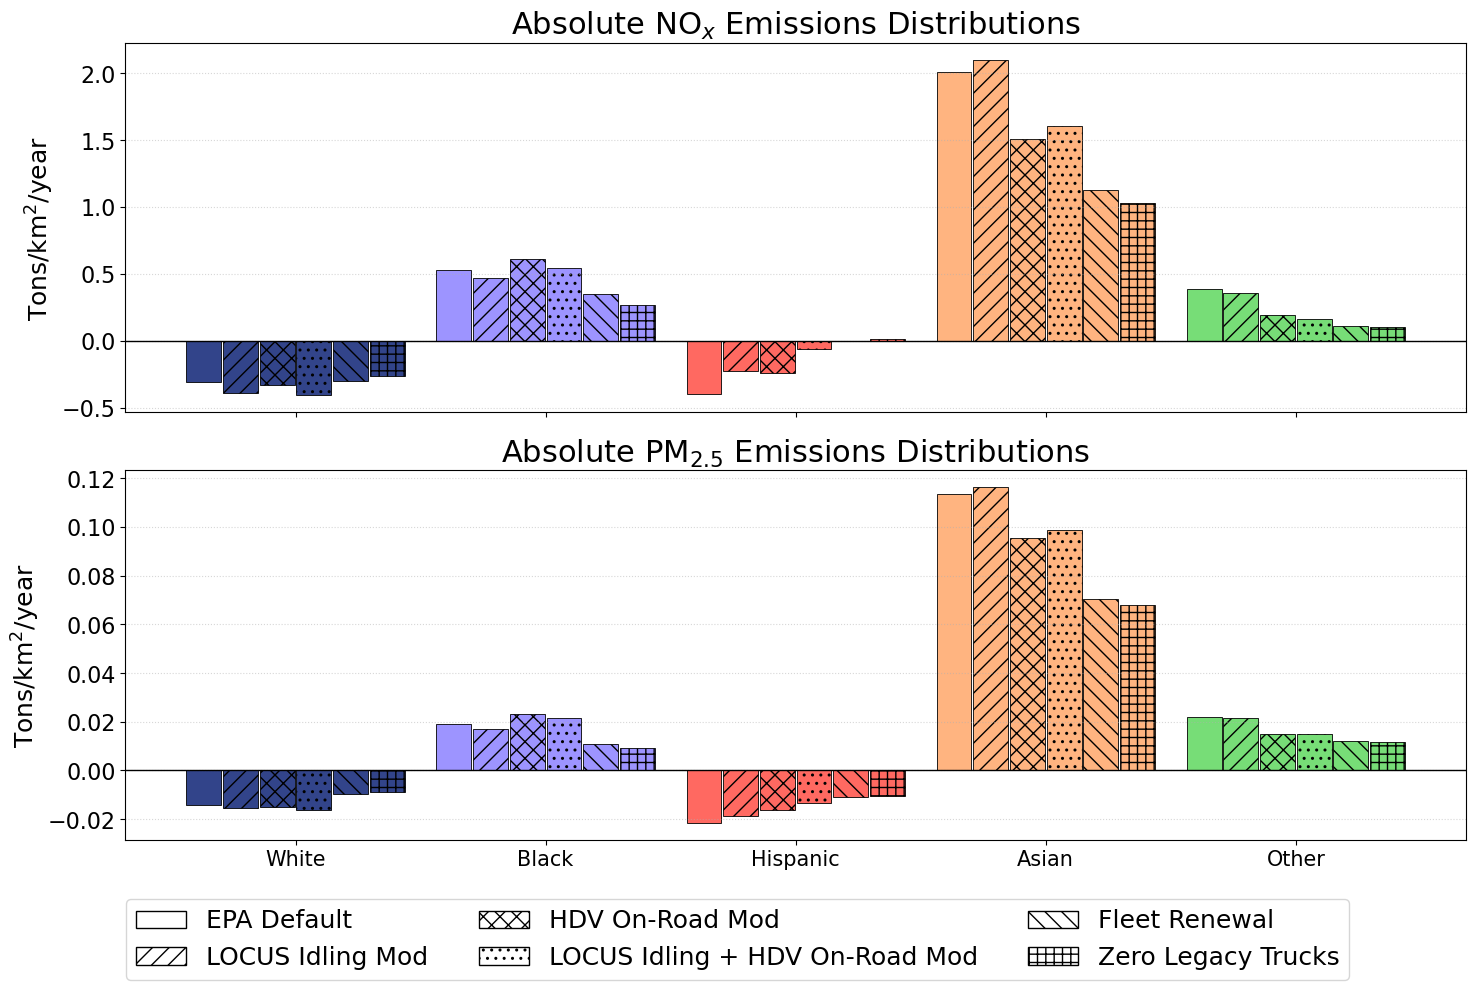

In [63]:
# ============================================================
# Absolute disparities bar plot
# ALL scenarios together
# ============================================================

subgroups = ["White","Black","Hispanic","Asian","Other"]

scenario_keys = ["Base","S1","S2","S3","Renewal","Zero"]

scenario_labels = [
    "EPA Default",
    "LOCUS Idling Mod",
    "HDV On-Road Mod",
    "LOCUS Idling + HDV On-Road Mod",
    "Fleet Renewal",
    "Zero Legacy Trucks"
]

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

hatches = {
    "Base": "",
    "S1": "//",
    "S2": "xx",
    "S3": "..",
    "Renewal": "\\\\",
    "Zero": "++"
}

# ============================================================
# CALCULATE ABSOLUTE DISPARITIES
# (group mean - scenario domain mean)
# ============================================================

nox_abs_plot = pd.DataFrame(index=subgroups)
pm_abs_plot = pd.DataFrame(index=subgroups)

for scen in scenario_keys:

    nox_abs_plot[scen] = [
        nox_means[scen]["White"]    - nox_means[scen]["Total"],
        nox_means[scen]["Black"]    - nox_means[scen]["Total"],
        nox_means[scen]["Hispanic"] - nox_means[scen]["Total"],
        nox_means[scen]["Asian"]    - nox_means[scen]["Total"],
        nox_means[scen]["Other"]    - nox_means[scen]["Total"],
    ]

    pm_abs_plot[scen] = [
        pm_means[scen]["White"]    - pm_means[scen]["Total"],
        pm_means[scen]["Black"]    - pm_means[scen]["Total"],
        pm_means[scen]["Hispanic"] - pm_means[scen]["Total"],
        pm_means[scen]["Asian"]    - pm_means[scen]["Total"],
        pm_means[scen]["Other"]    - pm_means[scen]["Total"],
    ]


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(2,1, figsize=(15,10), sharex=True)

x = np.arange(len(subgroups))

cluster_w = 0.88
bar_w = cluster_w / len(scenario_keys)

offsets = (
    np.arange(len(scenario_keys))
    - (len(scenario_keys)-1)/2
) * bar_w


# ============================================================
# NOX
# ============================================================

ax = axes[0]

for s, key in enumerate(scenario_keys):

    for i, g in enumerate(subgroups):

        ax.bar(
            x[i] + offsets[s],
            nox_abs_plot.loc[g, key],
            width=bar_w*0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)

ax.set_title("Absolute NO$_x$ Emissions Distributions", fontsize=22)

axes[0].set_ylabel("Tons/km$^2$/year", fontsize=18)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
axes[0].tick_params(axis="y", labelsize=16)



# ============================================================
# PM25
# ============================================================

ax = axes[1]

for s, key in enumerate(scenario_keys):

    for i, g in enumerate(subgroups):

        ax.bar(
            x[i] + offsets[s],
            pm_abs_plot.loc[g, key],
            width=bar_w*0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)

ax.set_title("Absolute PM$_{2.5}$ Emissions Distributions", fontsize=22)

axes[1].set_ylabel("Tons/km$^2$/year", fontsize=18)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
axes[1].tick_params(axis="y", labelsize=16)




# ============================================================
# X labels
# ============================================================

axes[1].set_xticks(x)

axes[1].set_xticklabels(subgroups, fontsize=15)


# ============================================================
# LEGEND
# ============================================================

scenario_patches = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatches[k],
        label=label
    )
    for k, label in zip(scenario_keys, scenario_labels)
]

fig.legend(
    handles=scenario_patches,
    loc="lower center",
    ncol=3,
    fontsize=18,
    frameon=True
)

plt.tight_layout(rect=[0,0.11,1,1])

plt.show()

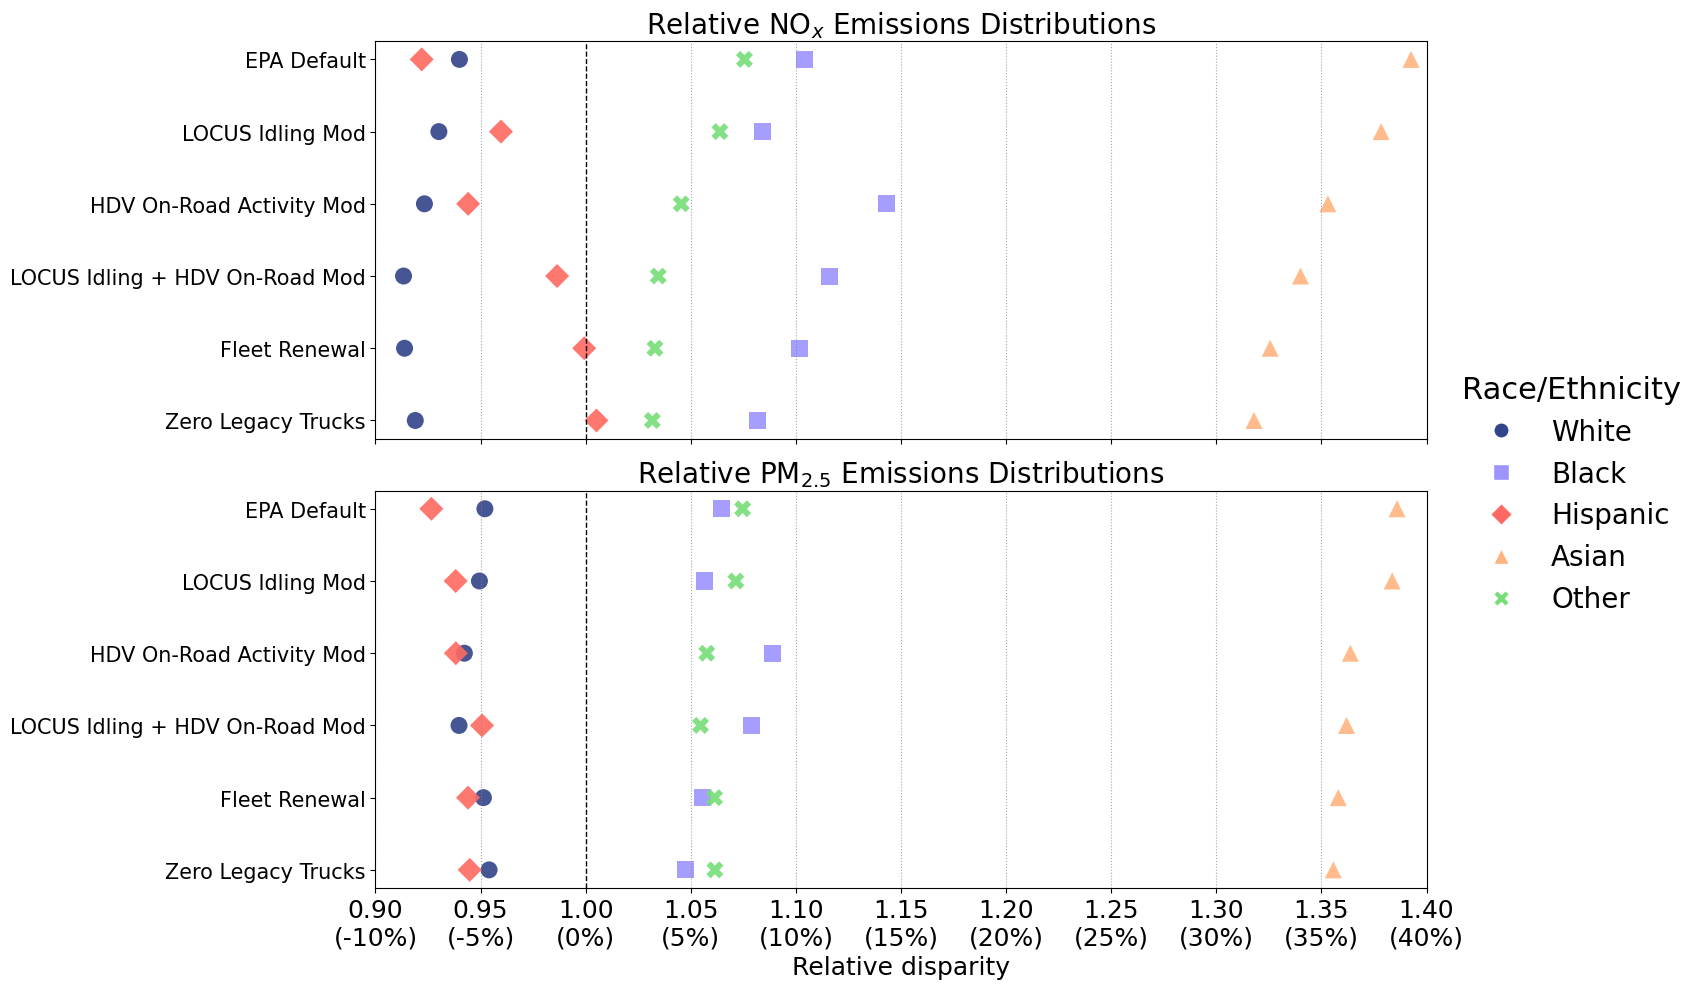

In [64]:
subgroups = ["White", "Black", "Hispanic", "Asian", "Other"]

markers = {
    "White": "o",
    "Black": "s",
    "Hispanic": "D",
    "Asian": "^",
    "Other": "X",
}

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

scenario_rows = [
    ("Zero Legacy Trucks", nox_tbl_rel, pm_tbl_rel, "Zero"),
    ("Fleet Renewal", nox_tbl_rel, pm_tbl_rel, "Renewal"),
    ("LOCUS Idling + HDV On-Road Mod", nox_tbl_rel, pm_tbl_rel, "S3"),
    ("HDV On-Road Activity Mod", nox_tbl_rel, pm_tbl_rel, "S2"),
    ("LOCUS Idling Mod", nox_tbl_rel, pm_tbl_rel, "S1"),
    ("EPA Default", nox_tbl_rel, pm_tbl_rel, "Base"),
]

xticks_diff = np.array([
    -0.10, -0.05, 0.00, 0.05, 0.10,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40
])

xtick_labels = [
    f"{1+d:.2f}\n({int(round(d*100)):d}%)"
    for d in xticks_diff
]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ============================================================
# NOx
# ============================================================

ax = axes[0]
ypos = np.arange(len(scenario_rows))

for j, (row_label, nox_tbl, pm_tbl, key) in enumerate(scenario_rows):
    for g in subgroups:
        x_val = nox_tbl.loc[g, f"{key}_Relative"] - 1.0

        ax.scatter(
            x_val,
            j,
            s=150,
            marker=markers[g],
            color=colors[g],
            alpha=0.9,
            edgecolor="none"
        )

ax.set_yticks(ypos)
ax.set_yticklabels([r[0] for r in scenario_rows], fontsize=15)
ax.set_title("Relative NO$_x$ Emissions Distributions", fontsize=20)
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.tick_params(axis="x", labelsize=14)

for x in xticks_diff:
    if x != 0:
        ax.axvline(x, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)


# ============================================================
# PM2.5
# ============================================================

ax = axes[1]

for j, (row_label, nox_tbl, pm_tbl, key) in enumerate(scenario_rows):
    for g in subgroups:
        x_val = pm_tbl.loc[g, f"{key}_Relative"] - 1.0

        ax.scatter(
            x_val,
            j,
            s=150,
            marker=markers[g],
            color=colors[g],
            alpha=0.9,
            edgecolor="none"
        )

ax.set_yticks(ypos)
ax.set_yticklabels([r[0] for r in scenario_rows], fontsize=15)
ax.set_xticks(xticks_diff)
ax.set_xticklabels(xtick_labels, fontsize=18)
ax.set_xlim(xticks_diff.min(), xticks_diff.max())
ax.set_title("Relative PM$_{2.5}$ Emissions Distributions", fontsize=20)
ax.set_xlabel("Relative disparity", fontsize=18)
ax.axvline(0, color="k", linestyle="--", linewidth=1)

for x in xticks_diff:
    if x != 0:
        ax.axvline(x, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)


# ============================================================
# Legend
# ============================================================

legend_handles = [
    Line2D(
        [0], [0],
        marker=markers[g],
        color="w",
        markerfacecolor=colors[g],
        markersize=11,
        label=g
    )
    for g in subgroups
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    frameon=False,
    title="Race/Ethnicity",
    title_fontsize=22,
    fontsize=20
)

plt.tight_layout(rect=[0, 0, 1.06, 1])
plt.show()